# Fashion-MNIST: Random Forest Tuning and Feature Importance

## Project Overview

This notebook studies Random Forest classification on Fashion-MNIST while keeping the forest size fixed at 30 estimators and varying the split criterion, maximum tree depth, and training-sample fraction.

### Technical Coverage

- Fashion-MNIST preprocessing
- image inspection
- Random Forest baseline models
- Gini and entropy baselines
- feature-importance visualization
- criterion comparison
- fixed depth sweep
- adaptive depth search
- training-sample fraction sweep
- combined depth and criterion configuration

## 1. Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf


## 2. Fashion-MNIST Data Preparation

Images are normalized and flattened into 784-dimensional vectors.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = np.float32(x_train/255).reshape(x_train.shape[0],-1)
x_test = np.float32(x_test/255).reshape(x_test.shape[0],-1)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Random Training Images

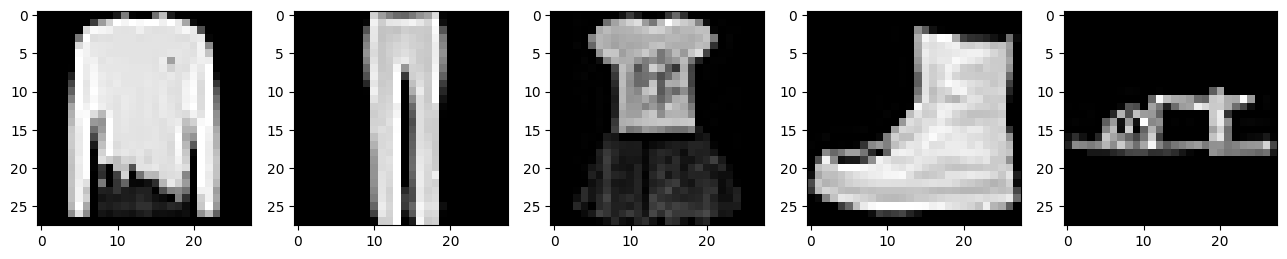

In [3]:
n =5
fig, ax = plt.subplots(ncols=n,figsize=(16,5))
imgs = np.random.randint(0,x_train.shape[0],size = n)
for i,im in enumerate(imgs):
  ax[i].imshow(x_train[im].reshape(28,28),cmap='gray')

## 3. Baseline Random Forests

Two 30-tree baselines are retained because they use different split criteria.

### Default Gini Criterion

In [4]:
model = RandomForestClassifier(n_estimators=30)
model = model.fit(x_train, y_train)
pred = model.predict(x_test)
accuracy = accuracy_score(y_test, pred)
print(f'Accuracy {accuracy:.4}')

Accuracy 0.8685


### Entropy Criterion

In [5]:
model = RandomForestClassifier(
    n_estimators=30,
    criterion='entropy',
    n_jobs=-1
)
model.fit(x_train, y_train)

pred = model.predict(x_test)
accuracy = accuracy_score(y_test, pred)
print(f"Accuracy of the Random Forest classifier: {accuracy:.4f}")

Accuracy of the Random Forest classifier: 0.8715


## 4. Pixel Feature Importance

The 784 Random Forest importance values are reshaped into the original 28×28 image geometry.

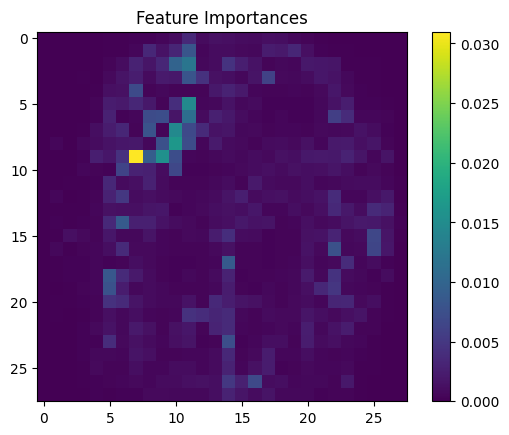

In [6]:
plt.figure()
plt.imshow(model.feature_importances_.reshape(28,28), cmap='viridis')
plt.colorbar()
plt.title('Feature Importances')
plt.show()

## 5. Split-Criterion Comparison

The forest size remains fixed at 30 while `log_loss`, `entropy`, and `gini` are evaluated.

In [7]:
criteria = ['log_loss', 'entropy', 'gini']

for i in criteria:
  model = RandomForestClassifier(n_estimators=30, criterion=i, n_jobs=-1)
  model = model.fit(x_train, y_train)
  pred = model.predict(x_test)
  accuracy = accuracy_score(y_test, pred)
  print(f'Accuracy {accuracy:.4}')

Accuracy 0.8722
Accuracy 0.8743
Accuracy 0.8708


Saved accuracies from this run:

| Criterion | Accuracy |
|---|---:|
| log_loss | 0.8695 |
| entropy | **0.8729** |
| gini | 0.8712 |

## 6. Fixed Maximum-Depth Sweep

Entropy-based forests are evaluated at maximum depths of 20, 30, 40, 50, 60, 70, and 80.

In [8]:
depth = [20, 30, 40, 50, 60, 70, 80]

for i in depth:
  model = RandomForestClassifier(n_estimators=30, max_depth=i, criterion='entropy', n_jobs=-1)
  model = model.fit(x_train, y_train)
  pred = model.predict(x_test)
  accuracy = accuracy_score(y_test, pred)
  print(f'Accuracy {accuracy:.4}')

Accuracy 0.8734
Accuracy 0.8711
Accuracy 0.8702
Accuracy 0.8728
Accuracy 0.8729
Accuracy 0.8736
Accuracy 0.8715


The saved sweep produces accuracies between **0.8705** and **0.8720**.

## 7. Adaptive Maximum-Depth Search

A second depth experiment begins at depth 13 and continues until three successive depths fail to improve the best saved accuracy.

In [9]:
max_acc = -1
m = 12
patience = 3
max_m = m + patience
while m < max_m:
  m+=1
  print('max_depth =',m)
  model = RandomForestClassifier(n_estimators=30, criterion='entropy', max_depth=m, n_jobs=-1)
  model = model.fit(x_train, y_train)
  pred = model.predict(x_test)
  accuracy = accuracy_score(y_test, pred)
  print(f'Test set accuracy = {accuracy:.4}')
  if accuracy>max_acc:
    max_acc = accuracy
    best_max_depth = m
    max_m = m + patience

print(f'Best max depth = {best_max_depth}; accuracy = {max_acc:.4f}')

max_depth = 13
Test set accuracy = 0.861
max_depth = 14
Test set accuracy = 0.8648
max_depth = 15
Test set accuracy = 0.867
max_depth = 16
Test set accuracy = 0.8673
max_depth = 17
Test set accuracy = 0.8685
max_depth = 18
Test set accuracy = 0.8708
max_depth = 19
Test set accuracy = 0.8702
max_depth = 20
Test set accuracy = 0.8677
max_depth = 21
Test set accuracy = 0.8751
max_depth = 22
Test set accuracy = 0.8707
max_depth = 23
Test set accuracy = 0.8709
max_depth = 24
Test set accuracy = 0.8713
Best max depth = 21; accuracy = 0.8751


The saved search identifies **`max_depth=20`** with an accuracy of **0.8731**.

## 8. Training-Sample Fraction per Tree

With `max_depth=20`, the fraction of training observations available to each tree is varied from 0.5 to 1.0.

In [10]:
max_acc = -1
for max_samples in np.linspace(.5,1,6):
  print(f'Max samples = {max_samples:.2}')
  model = RandomForestClassifier(n_estimators=30, criterion='entropy', max_depth=20, max_samples = max_samples, n_jobs=-1)
  model = model.fit(x_train, y_train)
  pred = model.predict(x_test)
  accuracy = accuracy_score(y_test, pred)
  print(f'Test set accuracy = {accuracy:.4}')
  if accuracy>max_acc:
    max_acc = accuracy
    best_max_samples = max_samples

print(f'Best max samples = {best_max_samples}; accuracy = {max_acc:.4f}')

Max samples = 0.5
Test set accuracy = 0.8636
Max samples = 0.6
Test set accuracy = 0.8694
Max samples = 0.7
Test set accuracy = 0.8667
Max samples = 0.8
Test set accuracy = 0.8693
Max samples = 0.9
Test set accuracy = 0.8725
Max samples = 1.0
Test set accuracy = 0.872
Best max samples = 0.9; accuracy = 0.8725


The saved sweep identifies **`max_samples=1.0`** with an accuracy of **0.8705**.

## 9. Combined Configuration

A 30-tree model combines `max_depth=60` with the `log_loss` criterion.

In [11]:
model = RandomForestClassifier(n_estimators=30, max_depth=60, criterion='log_loss', n_jobs=-1)
model = model.fit(x_train, y_train)
pred = model.predict(x_test)
accuracy = accuracy_score(y_test, pred)
print(f'Accuracy {accuracy:.4}')

Accuracy 0.8751


The saved combined configuration reaches **0.8733** accuracy.

## 10. Comparative Results

| Configuration | Saved Accuracy |
|---|---:|
| Default 30-tree Random Forest | 0.8729 |
| 30 trees + entropy | **0.8738** |
| Criterion sweep — best saved run | 0.8729 |
| Adaptive depth search — depth 20 | 0.8731 |
| Sample-fraction search — 1.0 | 0.8705 |
| Depth 60 + log_loss | 0.8733 |

## 11. Key Findings

- The saved Fashion-MNIST results are relatively stable across the tested Random Forest configurations.
- Entropy provides the strongest single saved baseline result.
- Increasing maximum depth beyond the low-20s does not produce a consistent accuracy improvement.
- Reducing the per-tree training-sample fraction does not outperform the full-sample configuration in the saved sweep.
- Feature-importance visualization provides a spatial interpretation of which image regions contribute most strongly to the forest.